# Exploratory Data Analysis on forbe's richest athlete (1990 - 2020) dataset.

## 1. Introduction
This dataset provides a historical look at the highest-paid athletes in the world between 1990 and 2020. It captures the commercial evolution of sports, showing how athlete earnings have transitioned from multi-million to multi-hundred-million dollar figures.

### Variables:
- **Name**: The name of the athlete.
- **Nationality**: The country the athlete represents.
- **Current Rank**: The athlete's rank in the Forbes list for that year.
- **Previous Year Rank**: The athlete's rank from the preceding year.
- **Sport**: The discipline or sport the athlete competes in.
- **Year**: The year of the list.
- **Earnings ($ million)**: Total annual earnings in millions of USD.

### Interest of Study:
This study is fascinating because it illustrates the globalization of sports, the dominance of certain eras by specific individuals (like Tiger Woods or Michael Jordan), and the massive financial growth of professional sports driven by broadcasting rights and global endorsements.

## 2. Cleaning the Data
In this section, we will:
- Standardize column names.
- Handle duplicates and missing values.
- Ensure data types are correct for analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset
df = pd.read_csv('Forbes Richest Athletes (Forbes Richest Athletes 1990-2020).csv')

# Remove duplicates
df = df.drop_duplicates()

# Standardize column names
df.columns = [col.strip().lower().replace('($ million)', 'usd_millions').replace(' ', '_').replace('.', '') for col in df.columns]

# Ensure earnings is numeric (it is already float in this dataset, but standardizing just in case)
if df['earnings_usd_millions'].dtype == 'object':
    df['earnings_usd_millions'] = df['earnings_usd_millions'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Ensure Year is integer
df['year'] = df['year'].astype(int)

# Handle missing data
# Decisions:
# 1. Drop rows with null earnings or nationality if they exist
df = df.dropna(subset=['earnings_usd_millions', 'nationality'])
# 2. Impute missing numeric data if needed (using median for earnings if we didn't drop them)
# For this specific Forbes dataset, the primary data points are usually complete.

# Standardize Sport names (cleaning casing and duplicates like 'boxing' vs 'Boxing')
df['sport'] = df['sport'].str.lower().str.strip()
df['sport'] = df['sport'].replace({
    'f1 motorsports': 'auto racing', 
    'f1 racing': 'auto racing', 
    'nascar': 'auto racing', 
    'soccer': 'soccer', 
    'football': 'soccer', # Checking names usually shows 'football' as soccer in international lists
    'american football / baseball': 'american football',
    'ice hockey': 'hockey'
})

print("Data cleaning complete.")
df.head()

Data cleaning complete.


,sno,name,nationality,current_rank,previous_year_rank,sport,year,earnings_usd_millions
0,1,Mike Tyson,USA,1,NaN,boxing,1990,28.6
1,2,Buster Douglas,USA,2,NaN,boxing,1990,26.0
2,3,Sugar Ray Leonard,USA,3,NaN,boxing,1990,13.0
3,4,Ayrton Senna,Brazil,4,NaN,auto racing,1990,10.0
4,5,Alain Prost,France,5,NaN,auto racing,1990,9.0


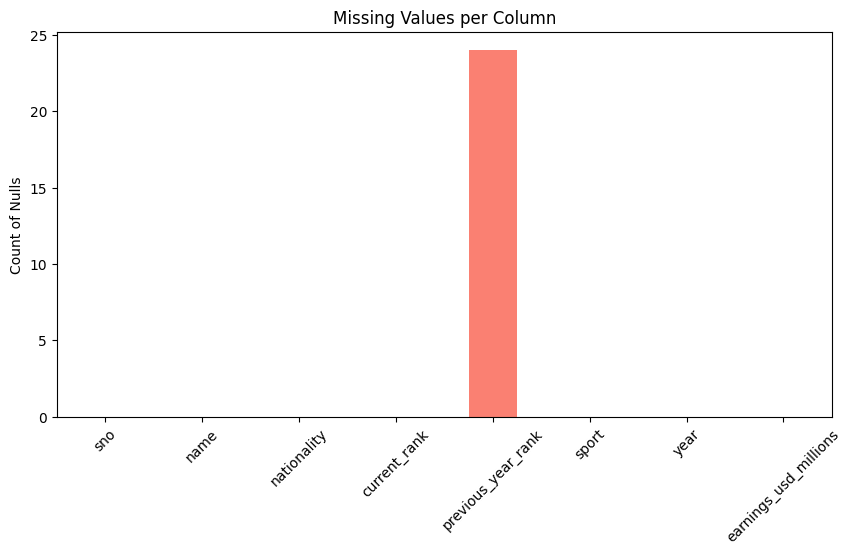

In [2]:
# Visualize missing values per column
plt.figure(figsize=(10, 5))
df.isnull().sum().plot(kind='bar', color='salmon')
plt.title('Missing Values per Column')
plt.ylabel('Count of Nulls')
plt.xticks(rotation=45)
plt.show()

## 3. Sections and Charts

### a. Earnings Trends Over Time
Growth of athlete earnings over the decades (1990 - 2020).

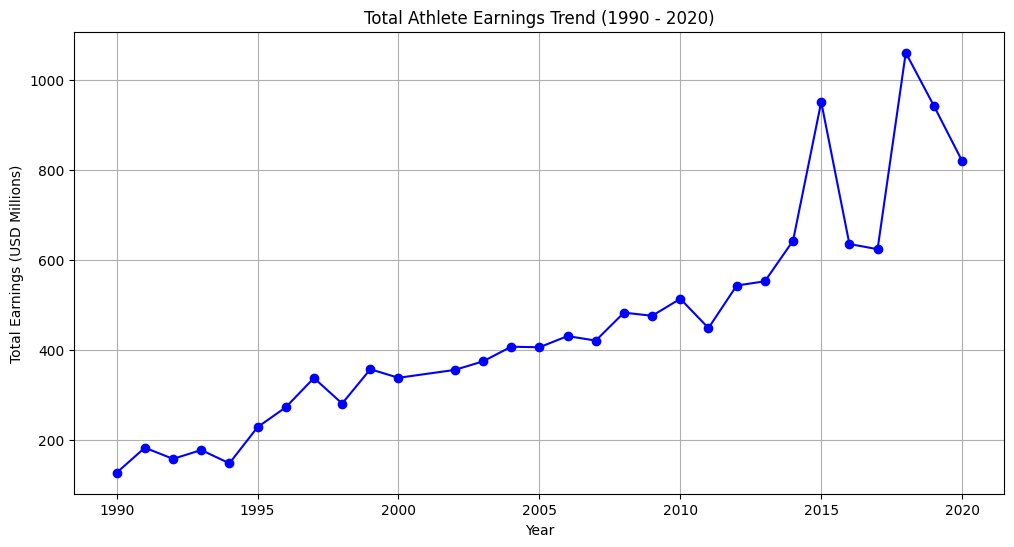

Insight: Earnings have seen a massive upward surge, especially after 2010, indicating the explosive growth in sports commercialization.


In [3]:
yearly_earnings = df.groupby('year')['earnings_usd_millions'].sum()
plt.figure(figsize=(12, 6))
plt.plot(yearly_earnings.index, yearly_earnings.values, marker='o', linestyle='-', color='b')
plt.title('Total Athlete Earnings Trend (1990 - 2020)')
plt.xlabel('Year')
plt.ylabel('Total Earnings (USD Millions)')
plt.grid(True)
plt.show()

print("Insight: Earnings have seen a massive upward surge, especially after 2010, indicating the explosive growth in sports commercialization.")

### b. Top Athlete by Decade
Who dominated amongst the athletes in each decade?

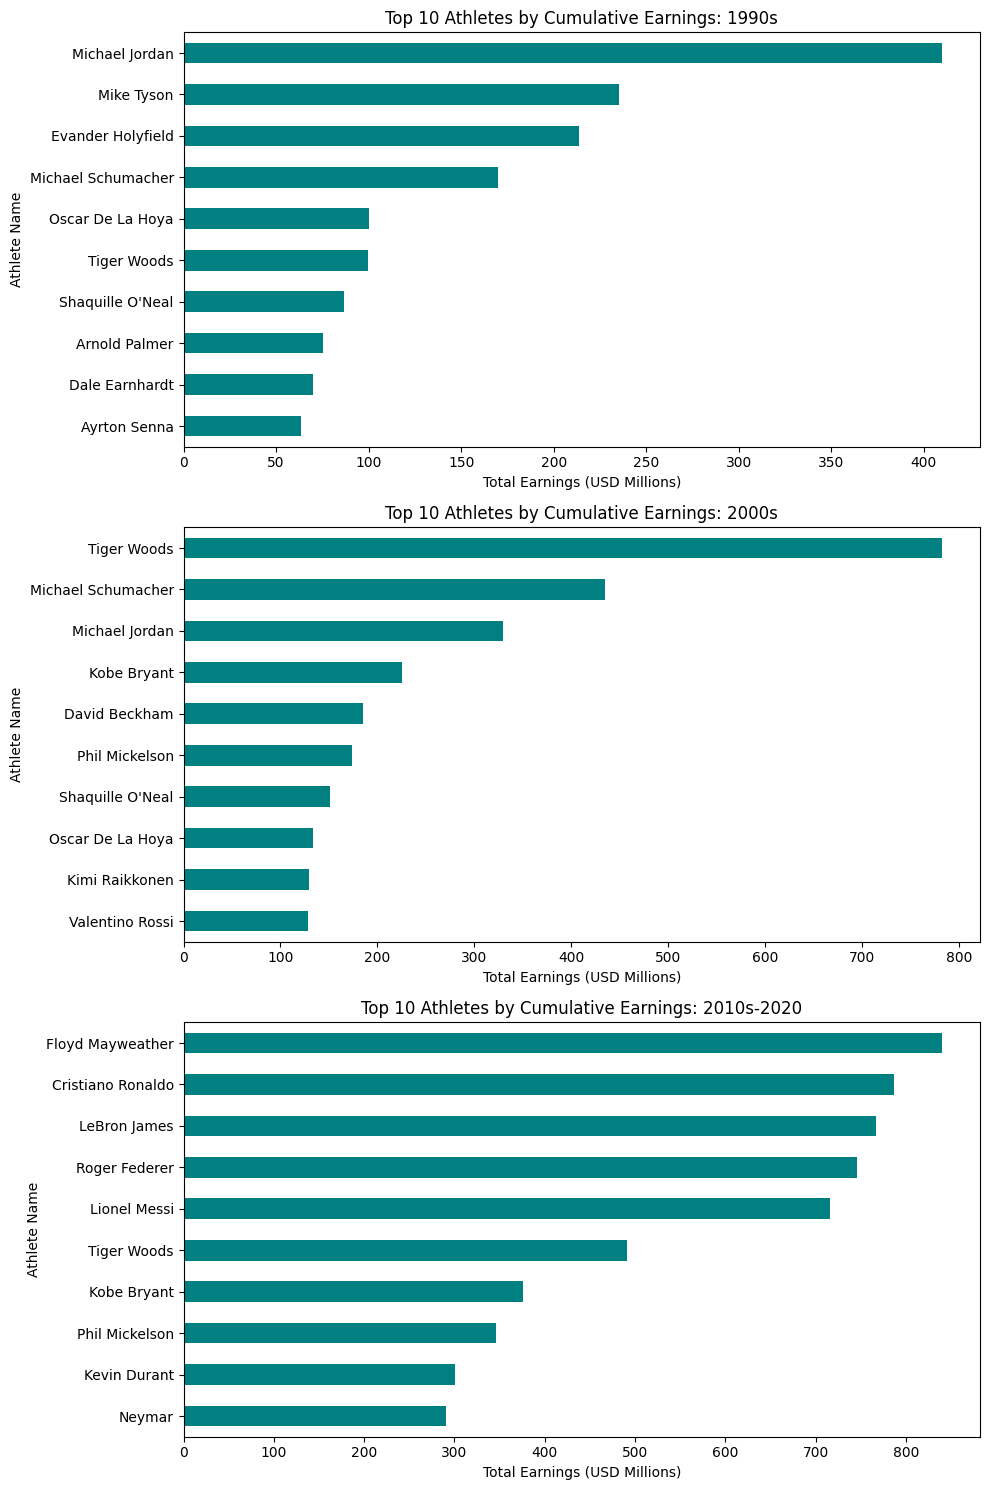

Insight: Dominance shifts from Michael Jordan and Mike Tyson (90s) to Tiger Woods (00s) and then to Mayweather, Messi, and Ronaldo (10s).


In [4]:
def get_decade(year):
    if year < 2000: return '1990s'
    elif year < 2010: return '2000s'
    else: return '2010s-2020'

df['decade'] = df['year'].apply(get_decade)

decades = sorted(df['decade'].unique())
fig, axes = plt.subplots(len(decades), 1, figsize=(10, 15))

for i, decade in enumerate(decades):
    top_athletes = df[df['decade'] == decade].groupby('name')['earnings_usd_millions'].sum().sort_values(ascending=False).head(10)
    top_athletes.sort_values().plot(kind='barh', ax=axes[i], color='teal')
    axes[i].set_title(f'Top 10 Athletes by Cumulative Earnings: {decade}')
    axes[i].set_xlabel('Total Earnings (USD Millions)')
    axes[i].set_ylabel('Athlete Name')

plt.tight_layout()
plt.show()

print("Insight: Dominance shifts from Michael Jordan and Mike Tyson (90s) to Tiger Woods (00s) and then to Mayweather, Messi, and Ronaldo (10s).")

### c. Earning by Sport
Which sport consistently produces the richest athletes?

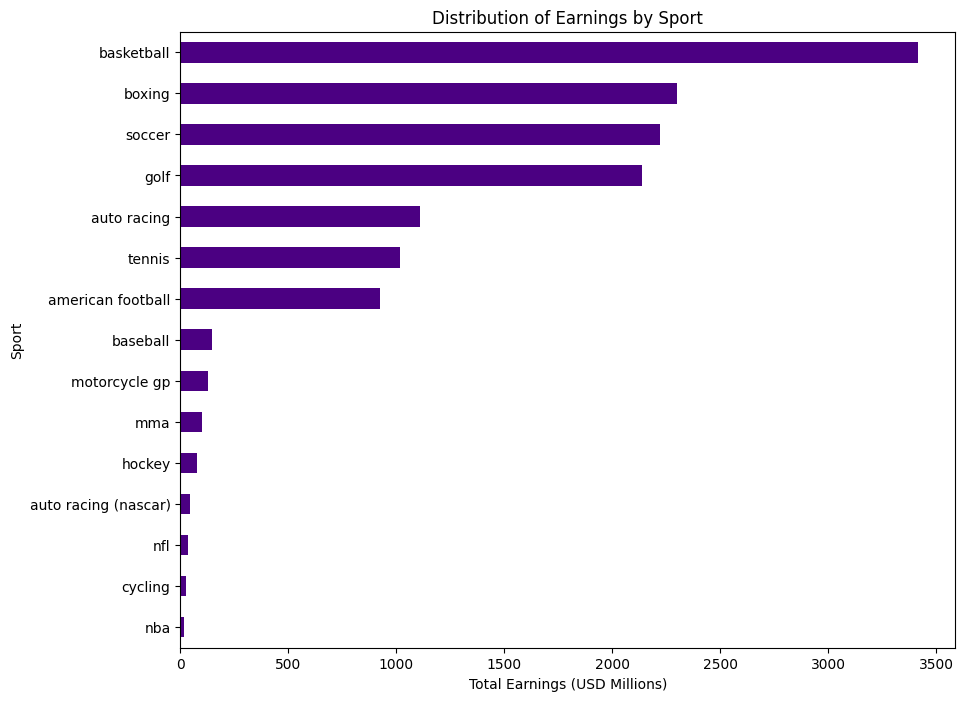

Insight: Basketball, Boxing, and Golf have historically generated the most wealth, with Soccer rising rapidly in recent years.


In [5]:
sport_earnings = df.groupby('sport')['earnings_usd_millions'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sport_earnings.sort_values().plot(kind='barh', color='indigo')
plt.title('Distribution of Earnings by Sport')
plt.xlabel('Total Earnings (USD Millions)')
plt.ylabel('Sport')
plt.show()

print("Insight: Basketball, Boxing, and Golf have historically generated the most wealth, with Soccer rising rapidly in recent years.")

### d. Nationality Breakdown
US dominance vs the rise of global stars.

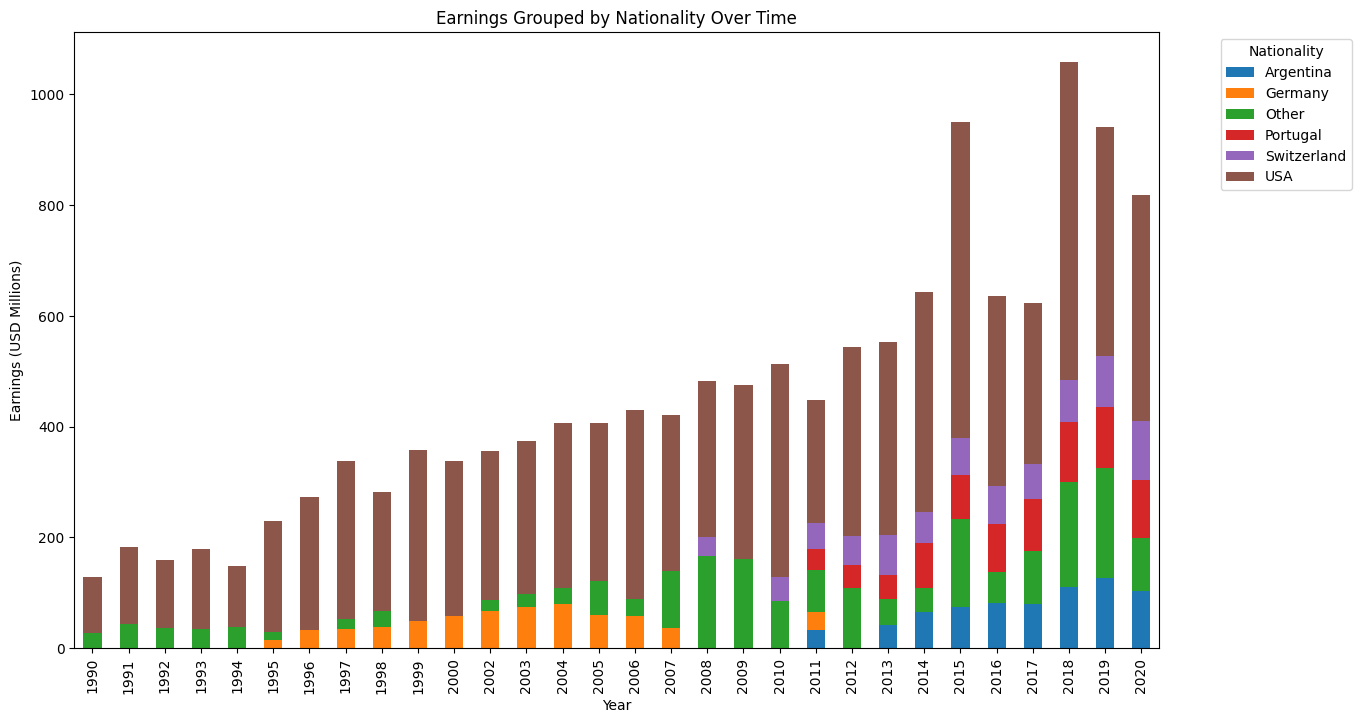

Insight: While the USA remains dominant, there is a clear trend of international athletes (especially from Europe and South America) taking larger shares of the top spots over time.


In [6]:
# Grouping small nationalities into 'Other'
top_nations = df.groupby('nationality')['earnings_usd_millions'].sum().sort_values(ascending=False).head(5).index.tolist()
df['nation_group'] = df['nationality'].apply(lambda x: x if x in top_nations else 'Other')

nat_pivot = df.pivot_table(index='year', columns='nation_group', values='earnings_usd_millions', aggfunc='sum').fillna(0)
nat_pivot.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Earnings Grouped by Nationality Over Time')
plt.xlabel('Year')
plt.ylabel('Earnings (USD Millions)')
plt.legend(title='Nationality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("Insight: While the USA remains dominant, there is a clear trend of international athletes (especially from Europe and South America) taking larger shares of the top spots over time.")

### e. Individual Athlete Comparison
Earnings trajectory of selected legends: Tiger Woods, Floyd Mayweather, and Cristiano Ronaldo.

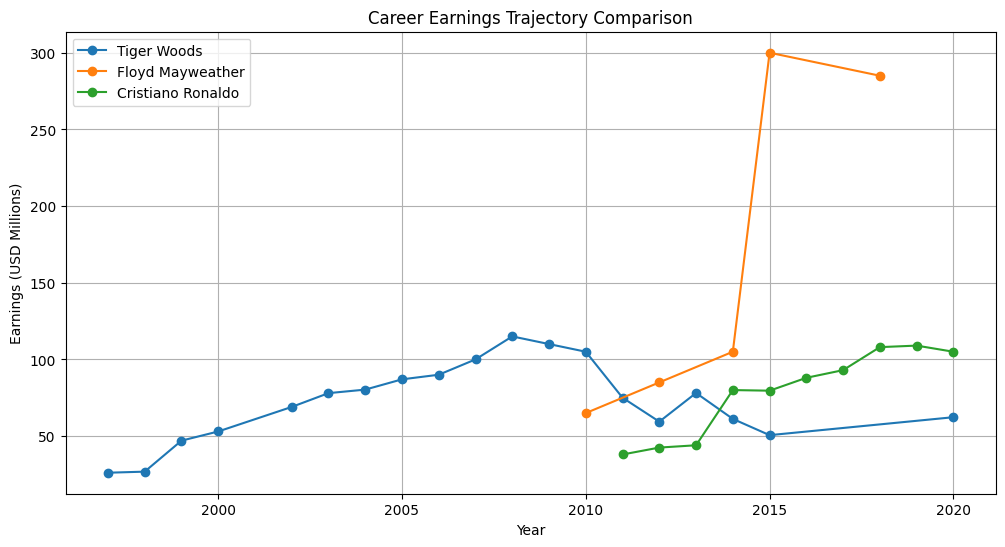

Insight: Woods shows a long steady peak, Mayweather has massive spikes for specific mega-fights, and Ronaldo shows the steady rise of soccer superstar branding.


In [7]:
selected = ['Tiger Woods', 'Floyd Mayweather', 'Cristiano Ronaldo']
plt.figure(figsize=(12, 6))

for athlete in selected:
    subset = df[df['name'] == athlete].sort_values('year')
    plt.plot(subset['year'], subset['earnings_usd_millions'], marker='o', label=athlete)

plt.title('Career Earnings Trajectory Comparison')
plt.xlabel('Year')
plt.ylabel('Earnings (USD Millions)')
plt.legend()
plt.grid(True)
plt.show()

print("Insight: Woods shows a long steady peak, Mayweather has massive spikes for specific mega-fights, and Ronaldo shows the steady rise of soccer superstar branding.")

### f. Outliers
Earnings vs. Year, highlighting extreme spikes.

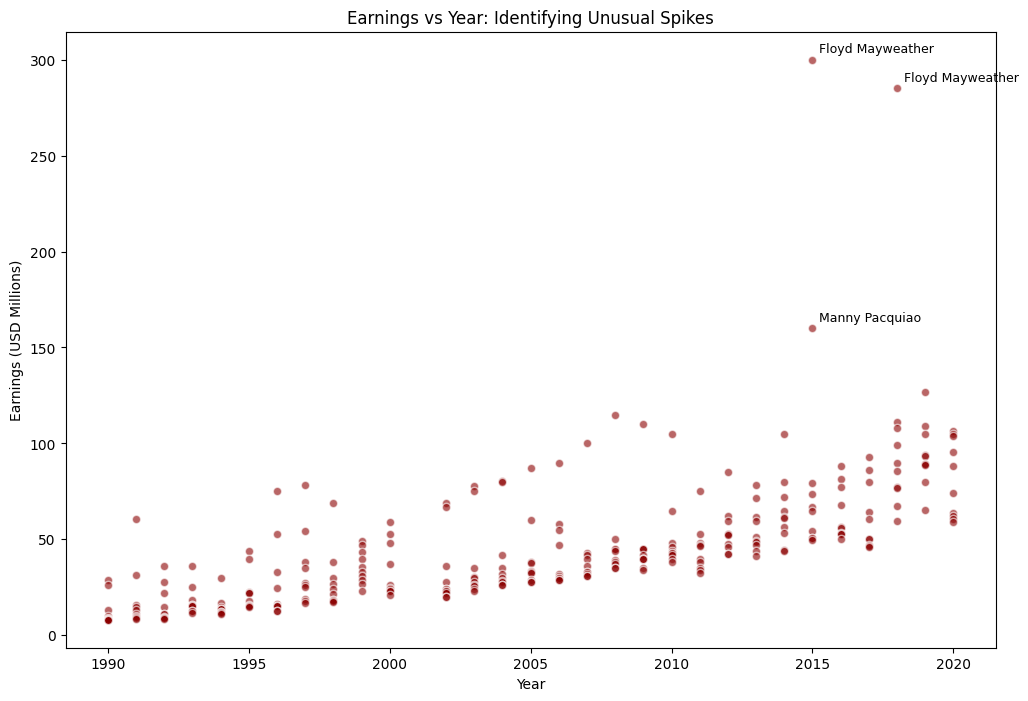

Insight: Extreme spikes are usually linked to rare events like Floyd Mayweather's multi-hundred million dollar fight nights.


In [8]:
plt.figure(figsize=(12, 8))
plt.scatter(df['year'], df['earnings_usd_millions'], alpha=0.6, color='darkred', edgecolors='white')

# Highlighting extreme outliers
outliers = df[df['earnings_usd_millions'] > 150]
for i, row in outliers.iterrows():
    plt.annotate(row['name'], (row['year'], row['earnings_usd_millions']), xytext=(5,5), textcoords='offset points', fontsize=9)

plt.title('Earnings vs Year: Identifying Unusual Spikes')
plt.xlabel('Year')
plt.ylabel('Earnings (USD Millions)')
plt.show()

print("Insight: Extreme spikes are usually linked to rare events like Floyd Mayweather's multi-hundred million dollar fight nights.")

## 4. Conclusion

- **Skyrocketing Earnings**: Athlete earnings skyrocketed post-2010/2020 due to global sponsorship and media rights. In 1990, the top earner made ~$28M, whereas by 2020, figures reached near $100M regularly.
- **Sport Dominance**: Basketball dominates in volume of top athletes, but Soccer and Boxing dominate the absolute top earning peaks in recent years. In the 90s, Boxing and Auto Racing were the primary sources of top wealth.
- **Nationalities**: US athletes led overall for decades, but the rise of global stars from Portugal, Argentina, and Switzerland shows that the market for sports superstardom is now truly global.
- **Limitations**: The dataset does not account for inflation, which would significantly increase the relative value of 1990s earnings. Some sports categorizations overlap (e.g., 'football' as soccer vs. american football), and the data ends at 2020, missing the recent Saudi Pro League and LIV Golf influence.

This report was written by: Mosa Khaholi, 
student at Hyperiondev (2026)